In [55]:
import os
import glob
from pathlib import Path

import cv2
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from tqdm.auto import tqdm

In [70]:
from dataclasses import dataclass


@dataclass
class CFG:

    MODEL_PATH = r"C:\Users\admin\Desktop\sandeep\FringeNet_best.pth"
    # MODEL_PATH = r"C:\Users\admin\Desktop\sandeep\checkpoints\epoch_050.pth"
    IMAGE_SIZE = 224

    INPUT_FOLDER = r"C:\Users\admin\Desktop\sandeep\data_2"

    OUTPUT_FOLDER = r"C:\Users\admin\Desktop\sandeep\data_2\aligned_vertical"

    # --------------------------------------------------------
    # IMAGE EXTENSIONS
    # --------------------------------------------------------
    EXTENSIONS = (
        "*.png",
        "*.jpg",
        "*.jpeg",
        "*.bmp",
        "*.tif",
        "*.tiff"
    )

    # --------------------------------------------------------
    # INFERENCE
    # --------------------------------------------------------
    USE_TTA = True
    DROPOUT = 0.20
    SAVE_AS_PNG = False
    OUTPUT_DIM = 2
    PNG_COMPRESSION = 3

    JPG_QUALITY = 100


cfg = CFG()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("FRINGENET ALIGNMENT")

print(f"Device        : {device}")
print(f"Model         : {cfg.MODEL_PATH}")
print(f"Input Folder  : {cfg.INPUT_FOLDER}")
print(f"Output Folder : {cfg.OUTPUT_FOLDER}")
print(f"TTA           : {cfg.USE_TTA}")


FRINGENET ALIGNMENT
Device        : cuda
Model         : C:\Users\admin\Desktop\sandeep\FringeNet_best.pth
Input Folder  : C:\Users\admin\Desktop\sandeep\data_2
Output Folder : C:\Users\admin\Desktop\sandeep\data_2\aligned_vertical
TTA           : True


In [71]:
def read_image(path):
    """
    Read grayscale image.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(path)

    return img


def zscore_normalize(img):
    """
    Zero mean, unit variance normalization.
    """

    img = img.astype(np.float32)

    mean = img.mean()

    std = img.std()

    return (img - mean) / (std + 1e-8)


def resize_with_padding(img, size):
    """
    Resize while preserving aspect ratio.
    Used ONLY for CNN inference.
    """

    h, w = img.shape

    scale = size / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    img = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros(
        (size, size),
        dtype=np.float32
    )

    y0 = (size - new_h) // 2

    x0 = (size - new_w) // 2

    canvas[
        y0:y0 + new_h,
        x0:x0 + new_w
    ] = img

    return canvas


def rotate_keep_size(image, angle):
    """
    Rotate ORIGINAL image while preserving dimensions.
    Black borders are used.
    """

    h, w = image.shape

    center = (w / 2, h / 2)

    M = cv2.getRotationMatrix2D(
        center,
        -angle,
        1.0
    )

    rotated = cv2.warpAffine(

        image,

        M,

        (w, h),

        flags=cv2.INTER_CUBIC,

        borderMode=cv2.BORDER_CONSTANT,

        borderValue=0

    )

    return rotated


def verticality_score(image):
    """
    FFT-based score.
    Higher = fringes are more vertical.
    """

    profile = np.sum(
        image.astype(np.float32),
        axis=0
    )

    profile -= profile.mean()

    fft = np.abs(
        np.fft.rfft(profile)
    )

    if len(fft) <= 1:
        return 0.0

    return fft[1:].max()


print("✓ Utility functions loaded.")

✓ Utility functions loaded.


In [72]:

# class FringeStem(nn.Module):
#     """
#     Initial feature extraction without aggressive downsampling.
#     """

#     def __init__(self, in_channels=1, out_channels=32):

#         super().__init__()

#         self.stem = nn.Sequential(

#             nn.Conv2d(
#                 in_channels,
#                 out_channels,
#                 kernel_size=3,
#                 stride=1,
#                 padding=1,
#                 bias=False
#             ),
#             nn.BatchNorm2d(out_channels),
#             nn.SiLU(inplace=True),

#             nn.Conv2d(
#                 out_channels,
#                 out_channels,
#                 kernel_size=3,
#                 stride=1,
#                 padding=1,
#                 bias=False
#             ),
#             nn.BatchNorm2d(out_channels),
#             nn.SiLU(inplace=True),

#             nn.Conv2d(
#                 out_channels,
#                 out_channels,
#                 kernel_size=3,
#                 stride=1,
#                 padding=1,
#                 bias=False
#             ),
#             nn.BatchNorm2d(out_channels),
#             nn.SiLU(inplace=True)

#         )

#     def forward(self, x):

#         return self.stem(x)

In [73]:
# ============================================================
# CELL 10 : FRINGENET STEM
# ============================================================

class FringeStem(nn.Module):
    """
    Initial feature extraction while preserving full spatial resolution.
    """

    def __init__(self, in_channels=1, out_channels=32):

        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels)
        )

        self.activation = nn.SiLU(inplace=True)

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):

        x = self.conv1(x)

        residual = x

        x = self.conv2(x)
        x = self.conv3(x)

        x = x + residual

        x = self.activation(x)

        return x


In [74]:
# class FringeResidualBlock(nn.Module):

#     def __init__(
#         self,
#         in_channels,
#         out_channels,
#         stride=1,
#         groups=8
#     ):

#         super().__init__()

#         self.conv1 = nn.Conv2d(
#             in_channels,
#             out_channels,
#             kernel_size=3,
#             stride=stride,
#             padding=1,
#             bias=False
#         )

#         self.norm1 = nn.GroupNorm(groups, out_channels)

#         self.act = nn.SiLU(inplace=True)

#         self.conv2 = nn.Conv2d(
#             out_channels,
#             out_channels,
#             kernel_size=3,
#             stride=1,
#             padding=1,
#             bias=False
#         )

#         self.norm2 = nn.GroupNorm(groups, out_channels)

#         # Skip connection
#         if stride != 1 or in_channels != out_channels:

#             self.shortcut = nn.Sequential(

#                 nn.Conv2d(
#                     in_channels,
#                     out_channels,
#                     kernel_size=1,
#                     stride=stride,
#                     bias=False
#                 ),

#                 nn.GroupNorm(groups, out_channels)

#             )

#         else:

#             self.shortcut = nn.Identity()

#     def forward(self, x):

#         identity = self.shortcut(x)

#         out = self.conv1(x)
#         out = self.norm1(out)
#         out = self.act(out)

#         out = self.conv2(out)
#         out = self.norm2(out)

#         out += identity

#         out = self.act(out)

#         return out

In [75]:
# ============================================================
# CELL 11 : RESIDUAL FRINGE BLOCK
# ============================================================

class FringeResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        groups=8
    ):

        super().__init__()

        # ----------------------------------------------------
        # Ensure GroupNorm groups divide channels
        # ----------------------------------------------------
        groups = min(groups, out_channels)

        while out_channels % groups != 0:
            groups -= 1

        # ----------------------------------------------------
        # Main Branch
        # ----------------------------------------------------
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.norm1 = nn.GroupNorm(groups, out_channels)

        self.act = nn.SiLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.norm2 = nn.GroupNorm(groups, out_channels)

        # ----------------------------------------------------
        # Shortcut
        # ----------------------------------------------------
        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.GroupNorm(groups, out_channels)

            )

        else:

            self.shortcut = nn.Identity()

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.norm2(out)

        out = out + identity

        out = self.act(out)

        return out


In [76]:

# class MultiScaleFringeBlock(nn.Module):

#     def __init__(self, channels, groups=8):

#         super().__init__()

#         branch_channels = channels // 4

#         # ----------------------------------------------------
#         # 3x3 Branch (Fine Fringes)
#         # ----------------------------------------------------
#         self.branch3 = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 padding=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # 5x5 Branch
#         # ----------------------------------------------------
#         self.branch5 = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=5,
#                 padding=2,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # 7x7 Branch
#         # ----------------------------------------------------
#         self.branch7 = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=7,
#                 padding=3,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # Dilated Branch
#         # ----------------------------------------------------
#         self.branch_dilated = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 padding=2,
#                 dilation=2,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # Feature Fusion
#         # ----------------------------------------------------
#         self.fuse = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 channels,
#                 kernel_size=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, channels),

#             nn.SiLU(inplace=True)

#         )

#     def forward(self, x):

#         b1 = self.branch3(x)
#         b2 = self.branch5(x)
#         b3 = self.branch7(x)
#         b4 = self.branch_dilated(x)

#         out = torch.cat(
#             [b1, b2, b3, b4],
#             dim=1
#         )

#         out = self.fuse(out)

#         return out + x

In [77]:
# ============================================================
# CELL 12 : MULTI-SCALE FRINGE BLOCK
# ============================================================

class MultiScaleFringeBlock(nn.Module):

    def __init__(self, channels, groups=8):

        super().__init__()

        branch_channels = channels // 4

        # Make sure GroupNorm is valid
        groups = min(groups, branch_channels)
        while branch_channels % groups != 0:
            groups -= 1

        # ----------------------------------------------------
        # Branch 1 : Local Features
        # ----------------------------------------------------
        self.branch1 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=1,
                dilation=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Branch 2 : Medium Receptive Field
        # ----------------------------------------------------
        self.branch2 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=2,
                dilation=2,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Branch 3 : Large Receptive Field
        # ----------------------------------------------------
        self.branch3 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=3,
                dilation=3,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Branch 4 : Global Context
        # ----------------------------------------------------
        self.branch4 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=4,
                dilation=4,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Feature Fusion
        # ----------------------------------------------------
        self.fuse = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(min(8, channels), channels),

            nn.SiLU(inplace=True)

        )

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        out = torch.cat(
            [b1, b2, b3, b4],
            dim=1
        )

        out = self.fuse(out)

        return out + x

# # ============================================================
# # CELL 12 : MULTI-SCALE FRINGE BLOCK
# # ============================================================

# class MultiScaleFringeBlock(nn.Module):

#     def __init__(self, channels, groups=8):

#         super().__init__()

#         branch_channels = channels // 4

#         # ----------------------------------------------------
#         # 3x3 Branch (Fine Fringes)
#         # ----------------------------------------------------
#         self.branch3 = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 padding=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # 5x5 Branch
#         # ----------------------------------------------------
#         self.branch5 = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=5,
#                 padding=2,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # 7x7 Branch
#         # ----------------------------------------------------
#         self.branch7 = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=7,
#                 padding=3,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # Dilated Branch
#         # ----------------------------------------------------
#         self.branch_dilated = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 padding=2,
#                 dilation=2,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # ----------------------------------------------------
#         # Feature Fusion
#         # ----------------------------------------------------
#         self.fuse = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 channels,
#                 kernel_size=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, channels),

#             nn.SiLU(inplace=True)

#         )

#     def forward(self, x):

#         b1 = self.branch3(x)
#         b2 = self.branch5(x)
#         b3 = self.branch7(x)
#         b4 = self.branch_dilated(x)

#         out = torch.cat(
#             [b1, b2, b3, b4],
#             dim=1
#         )

#         out = self.fuse(out)

#         return out + x

In [78]:

# class DirectionalBlock(nn.Module):

#     def __init__(self, channels, groups=8):

#         super().__init__()

#         branch_channels = channels // 4

#         # Horizontal Features
#         self.horizontal = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=(1,9),
#                 padding=(0,4),
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Vertical Features
#         self.vertical = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=(9,1),
#                 padding=(4,0),
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Local Features
#         self.local = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 padding=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Context Features
#         self.context = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 dilation=2,
#                 padding=2,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Fuse
#         self.fuse = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 channels,
#                 kernel_size=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, channels),

#             nn.SiLU(inplace=True)

#         )

#     def forward(self, x):

#         h = self.horizontal(x)

#         v = self.vertical(x)

#         l = self.local(x)

#         c = self.context(x)

#         out = torch.cat([h, v, l, c], dim=1)

#         out = self.fuse(out)

#         return out + x

In [79]:
# ============================================================
# CELL 13 : DIRECTIONAL CONVOLUTION BLOCK
# ============================================================

class DirectionalBlock(nn.Module):

    def __init__(self, channels, groups=8):

        super().__init__()

        branch_channels = channels // 4

        # ----------------------------------------------------
        # Ensure valid GroupNorm groups
        # ----------------------------------------------------
        groups = min(groups, branch_channels)
        while branch_channels % groups != 0:
            groups -= 1

        # ----------------------------------------------------
        # Horizontal Branch
        # ----------------------------------------------------
        self.horizontal = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=(1, 9),
                padding=(0, 4),
                groups=channels,
                bias=False
            ),

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Vertical Branch
        # ----------------------------------------------------
        self.vertical = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=(9, 1),
                padding=(4, 0),
                groups=channels,
                bias=False
            ),

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Local Branch
        # ----------------------------------------------------
        self.local = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Context Branch
        # ----------------------------------------------------
        self.context = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                dilation=2,
                padding=2,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Fusion
        # ----------------------------------------------------
        self.fuse = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(min(8, channels), channels),

            nn.SiLU(inplace=True)

        )

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        h = self.horizontal(x)
        v = self.vertical(x)
        l = self.local(x)
        c = self.context(x)

        out = torch.cat(
            [h, v, l, c],
            dim=1
        )

        out = self.fuse(out)

        return out + x

# # ============================================================
# # CELL 13 : DIRECTIONAL CONVOLUTION BLOCK
# # ============================================================

# class DirectionalBlock(nn.Module):

#     def __init__(self, channels, groups=8):

#         super().__init__()

#         branch_channels = channels // 4

#         # Horizontal Features
#         self.horizontal = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=(1,9),
#                 padding=(0,4),
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Vertical Features
#         self.vertical = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=(9,1),
#                 padding=(4,0),
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Local Features
#         self.local = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 padding=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Context Features
#         self.context = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 branch_channels,
#                 kernel_size=3,
#                 dilation=2,
#                 padding=2,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, branch_channels),

#             nn.SiLU(inplace=True)

#         )

#         # Fuse
#         self.fuse = nn.Sequential(

#             nn.Conv2d(
#                 channels,
#                 channels,
#                 kernel_size=1,
#                 bias=False
#             ),

#             nn.GroupNorm(groups, channels),

#             nn.SiLU(inplace=True)

#         )

#     def forward(self, x):

#         h = self.horizontal(x)

#         v = self.vertical(x)

#         l = self.local(x)

#         c = self.context(x)

#         out = torch.cat([h, v, l, c], dim=1)

#         out = self.fuse(out)

#         return out + x

In [80]:

# import torch.nn.functional as F

# class FringeNet(nn.Module):

#     def __init__(self, in_channels=1):

#         super().__init__()

#         # -------------------------------
#         # Stem
#         # -------------------------------
#         self.stem = FringeStem(
#             in_channels=in_channels,
#             out_channels=32
#         )

#         # -------------------------------
#         # Stage 1
#         # -------------------------------
#         self.stage1 = nn.Sequential(

#             FringeResidualBlock(32, 32),

#             MultiScaleFringeBlock(32)

#         )

#         # -------------------------------
#         # Stage 2
#         # -------------------------------
#         self.stage2 = nn.Sequential(

#             FringeResidualBlock(
#                 32,
#                 64,
#                 stride=2
#             ),

#             MultiScaleFringeBlock(64)

#         )

#         # -------------------------------
#         # Stage 3
#         # -------------------------------
#         self.stage3 = nn.Sequential(

#             FringeResidualBlock(
#                 64,
#                 128,
#                 stride=2
#             ),

#             DirectionalBlock(128)

#         )

#         # -------------------------------
#         # Stage 4
#         # -------------------------------
#         self.stage4 = nn.Sequential(

#             FringeResidualBlock(
#                 128,
#                 256,
#                 stride=2
#             ),

#             DirectionalBlock(256)

#         )

#         # -------------------------------
#         # Global Pooling
#         # -------------------------------
#         self.pool = nn.AdaptiveAvgPool2d(1)

#         # -------------------------------
#         # Regression Head
#         # -------------------------------
#         self.head = nn.Sequential(

#             nn.Flatten(),

#             nn.Linear(256, 128),

#             nn.SiLU(),

#             nn.Dropout(0.30),

#             nn.Linear(128, 64),

#             nn.SiLU(),

#             nn.Dropout(0.20),

#             # Predict [sin(theta), cos(theta)]
#             nn.Linear(64, 2)

#         )

#     def forward(self, x):

#         x = self.stem(x)

#         x = self.stage1(x)

#         x = self.stage2(x)

#         x = self.stage3(x)

#         x = self.stage4(x)

#         x = self.pool(x)

#         x = self.head(x)

#         # Normalize so ||output|| = 1
#         x = F.normalize(x, p=2, dim=1)

#         return x

In [81]:
# ============================================================
# CELL 14 : FRINGENET
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class FringeNet(nn.Module):

    def __init__(self, in_channels=1):

        super().__init__()

        # ----------------------------------------------------
        # Stem
        # ----------------------------------------------------
        self.stem = FringeStem(
            in_channels=in_channels,
            out_channels=32
        )

        # ----------------------------------------------------
        # Stage 1
        # ----------------------------------------------------
        self.stage1 = nn.Sequential(

            FringeResidualBlock(32, 32),

            MultiScaleFringeBlock(32)

        )

        # ----------------------------------------------------
        # Stage 2
        # ----------------------------------------------------
        self.stage2 = nn.Sequential(

            FringeResidualBlock(
                32,
                64,
                stride=2
            ),

            MultiScaleFringeBlock(64)

        )

        # ----------------------------------------------------
        # Stage 3
        # ----------------------------------------------------
        self.stage3 = nn.Sequential(

            FringeResidualBlock(
                64,
                128,
                stride=2
            ),

            DirectionalBlock(128)

        )

        # ----------------------------------------------------
        # Stage 4
        # ----------------------------------------------------
        self.stage4 = nn.Sequential(

            FringeResidualBlock(
                128,
                256,
                stride=2
            ),

            DirectionalBlock(256)

        )

        # ----------------------------------------------------
        # Dual Global Pooling
        # ----------------------------------------------------
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.maxpool = nn.AdaptiveMaxPool2d(1)

        # ----------------------------------------------------
        # Regression Head
        # ----------------------------------------------------
        self.head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(512, 256),

            nn.SiLU(inplace=True),

            nn.Dropout(cfg.DROPOUT),

            nn.Linear(256, 128),

            nn.SiLU(inplace=True),

            nn.Dropout(cfg.DROPOUT * 0.5),

            nn.Linear(128, cfg.OUTPUT_DIM)

        )

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Linear):

                nn.init.kaiming_normal_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):

        x = self.stem(x)

        x = self.stage1(x)

        x = self.stage2(x)

        x = self.stage3(x)

        x = self.stage4(x)

        avg = self.avgpool(x)

        mx = self.maxpool(x)

        x = torch.cat([avg, mx], dim=1)

        x = self.head(x)

        x = F.normalize(x, p=2, dim=1)

        return x

# # ============================================================
# # CELL 14 : FRINGENET
# # ============================================================

# import torch.nn.functional as F

# class FringeNet(nn.Module):

#     def __init__(self, in_channels=1):

#         super().__init__()

#         # -------------------------------
#         # Stem
#         # -------------------------------
#         self.stem = FringeStem(
#             in_channels=in_channels,
#             out_channels=32
#         )

#         # -------------------------------
#         # Stage 1
#         # -------------------------------
#         self.stage1 = nn.Sequential(

#             FringeResidualBlock(32, 32),

#             MultiScaleFringeBlock(32)

#         )

#         # -------------------------------
#         # Stage 2
#         # -------------------------------
#         self.stage2 = nn.Sequential(

#             FringeResidualBlock(
#                 32,
#                 64,
#                 stride=2
#             ),

#             MultiScaleFringeBlock(64)

#         )

#         # -------------------------------
#         # Stage 3
#         # -------------------------------
#         self.stage3 = nn.Sequential(

#             FringeResidualBlock(
#                 64,
#                 128,
#                 stride=2
#             ),

#             DirectionalBlock(128)

#         )

#         # -------------------------------
#         # Stage 4
#         # -------------------------------
#         self.stage4 = nn.Sequential(

#             FringeResidualBlock(
#                 128,
#                 256,
#                 stride=2
#             ),

#             DirectionalBlock(256)

#         )

#         # -------------------------------
#         # Global Pooling
#         # -------------------------------
#         self.pool = nn.AdaptiveAvgPool2d(1)

#         # -------------------------------
#         # Regression Head
#         # -------------------------------
#         self.head = nn.Sequential(

#             nn.Flatten(),

#             nn.Linear(256, 128),

#             nn.SiLU(),

#             nn.Dropout(0.30),

#             nn.Linear(128, 64),

#             nn.SiLU(),

#             nn.Dropout(0.20),

#             # Predict [sin(theta), cos(theta)]
#             nn.Linear(64, 2)

#         )

#     def forward(self, x):

#         x = self.stem(x)

#         x = self.stage1(x)

#         x = self.stage2(x)

#         x = self.stage3(x)

#         x = self.stage4(x)

#         x = self.pool(x)

#         x = self.head(x)

#         # Normalize so ||output|| = 1
#         x = F.normalize(x, p=2, dim=1)

#         return x

In [82]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FringeNet().to(device)

checkpoint = torch.load(
    cfg.MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model"])

model.eval()
print("FringeNet Loaded Successfully")
if "best_mae" in checkpoint:
    print(f"Best MAE : {checkpoint['best_mae']:.3f}°")

if "epoch" in checkpoint:
    print(f"Epoch    : {checkpoint['epoch']+1}")



# ============================================================
# HELPER FUNCTIONS
# ============================================================

def vector_to_angle(vec):
    """
    vec = [sin(theta), cos(theta)]
    returns angle in degrees (-180,180]
    """
    return np.degrees(np.arctan2(vec[0], vec[1]))


def angle_to_vector(angle):
    """
    angle (degrees)
    returns [sin(theta), cos(theta)]
    """
    theta = np.deg2rad(angle)

    return np.array(
        [
            np.sin(theta),
            np.cos(theta)
        ],
        dtype=np.float32
    )


def wrap_angle(angle):
    """
    Wrap angle into [-180,180)
    """
    return (angle + 180) % 360 - 180


# ------------------------------------------------------------
# Quick sanity check
# ------------------------------------------------------------

x = torch.randn(2, 1, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE).to(device)

with torch.no_grad():

    y = model(x)

print("Output Shape :", y.shape)

print("Vector Norms :", torch.norm(y, dim=1))

FringeNet Loaded Successfully
Best MAE : 1.174°
Epoch    : 56
Output Shape : torch.Size([2, 2])
Vector Norms : tensor([1., 1.], device='cuda:0')


In [83]:
# ============================================================
# CELL 6 : PREDICTION + TEST TIME AUGMENTATION
# ============================================================

def preprocess_for_network(image):
    """
    Prepare image for FringeNet.
    """
    img = zscore_normalize(image)

    img = resize_with_padding(
        img,
        cfg.IMAGE_SIZE
    )

    img = torch.from_numpy(img)

    img = img.unsqueeze(0).unsqueeze(0)

    return img.float().to(device)


def predict_vector(image):
    """
    Returns normalized [sin(theta), cos(theta)].
    """

    inp = preprocess_for_network(image)

    with torch.no_grad():

        pred = model(inp)

    return pred.squeeze(0).cpu().numpy()


def vector_to_angle(vec):
    """
    [sin(theta), cos(theta)] -> degrees
    """

    return np.degrees(
        np.arctan2(
            vec[0],
            vec[1]
        )
    )


def predict_angle(image):
    """
    Prediction without TTA.
    """

    vec = predict_vector(image)

    return vector_to_angle(vec)


# ------------------------------------------------------------
# TEST TIME AUGMENTATION
# ------------------------------------------------------------

def predict_angle_tta(image):
    """
    Original
    Horizontal Flip
    Vertical Flip

    Average in sin/cos space.
    """

    if not cfg.USE_TTA:

        return predict_angle(image)

    vectors = []

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    vectors.append(
        predict_vector(image)
    )

    # --------------------------------------------------------
    # Horizontal Flip
    # theta -> 180 - theta
    # --------------------------------------------------------

    img = cv2.flip(image, 1)

    v = predict_vector(img)

    angle = vector_to_angle(v)

    angle = 180 - angle

    vectors.append(
        angle_to_vector(angle)
    )

    # --------------------------------------------------------
    # Vertical Flip
    # theta -> -theta
    # --------------------------------------------------------

    img = cv2.flip(image, 0)

    v = predict_vector(img)

    angle = vector_to_angle(v)

    angle = -angle

    vectors.append(
        angle_to_vector(angle)
    )

    # --------------------------------------------------------
    # Average
    # --------------------------------------------------------

    vectors = np.asarray(vectors)

    mean_vec = vectors.mean(axis=0)

    mean_vec /= np.linalg.norm(mean_vec) + 1e-8

    angle = vector_to_angle(mean_vec)

    return wrap_angle(angle)


print("✓ Prediction functions loaded.")

✓ Prediction functions loaded.


In [84]:
# ============================================================
# CELL 7 : ALIGN A SINGLE IMAGE
# ============================================================

def align_image(image):
    """
    Align fringes vertically.

    Returns
    -------
    aligned_image
    final_angle
    verticality_score
    """

    # --------------------------------------------------------
    # Predict orientation
    # --------------------------------------------------------
    theta = predict_angle_tta(image)

    # --------------------------------------------------------
    # Candidate rotations
    # --------------------------------------------------------
    candidates = [

        theta,

        theta + 90.0

    ]

    best_score = -np.inf

    best_angle = None

    best_image = None

    # --------------------------------------------------------
    # Evaluate both candidates
    # --------------------------------------------------------
    for angle in candidates:

        rotated = rotate_keep_size(
            image,
            angle
        )

        score = verticality_score(rotated)

        if score > best_score:

            best_score = score

            best_angle = angle

            best_image = rotated

    best_angle = wrap_angle(best_angle)

    return best_image, best_angle, best_score


print("✓ Alignment function ready.")

✓ Alignment function ready.


In [67]:
# ============================================================
# CELL 8 : ALIGN COMPLETE FOLDER
# ============================================================

from pathlib import Path
from tqdm.auto import tqdm


def align_folder(
    input_root,
    output_root,
    suffix="_aligned"
):

    input_root = Path(input_root)
    output_root = Path(output_root)

    exts = {
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    }

    image_files = []

    for ext in exts:
        image_files.extend(input_root.rglob(f"*{ext}"))

    image_files = sorted(image_files)

    print("="*60)
    print(f"Found {len(image_files)} images")
    print("="*60)

    for image_path in tqdm(image_files):

        try:

            # ------------------------------------------
            # Read original image
            # ------------------------------------------
            image = read_image(str(image_path))

            # ------------------------------------------
            # Predict angle
            # ------------------------------------------
            theta = predict_angle_tta(image)

            # ------------------------------------------
            # Align
            # ------------------------------------------
            aligned = rotate_keep_size(
                image,
                -theta
            )

            # ------------------------------------------
            # Preserve folder structure
            # ------------------------------------------
            relative_folder = image_path.parent.relative_to(input_root)

            save_folder = output_root / relative_folder

            save_folder.mkdir(
                parents=True,
                exist_ok=True
            )

            save_name = (
                image_path.stem +
                suffix +
                image_path.suffix
            )

            save_path = save_folder / save_name

            cv2.imwrite(
                str(save_path),
                aligned
            )

        except Exception as e:

            print(f"Error : {image_path}")
            print(e)

    print("\nDone.")
    print(f"Saved to : {output_root}")

In [85]:
align_folder(

    input_root=r"C:\Users\admin\Desktop\sandeep\data_2",

    output_root=r"C:\Users\admin\Desktop\sandeep\data_2_aligned_1174"

)

Found 2792 images


  0%|          | 0/2792 [00:00<?, ?it/s]


Done.
Saved to : C:\Users\admin\Desktop\sandeep\data_2_aligned_1174


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def generate_fringe(size=128, freq=10, angle=0.0, visibility=1.0):
    """
    Generates synthetic 2D fringe pattern.
    
    angle: phase shift (radians)
    freq : fringe frequency
    """
    x = np.linspace(0, 1, size)
    X, Y = np.meshgrid(x, x)

    # rotate coordinate system to simulate tilt
    Xr = X * np.cos(angle) + Y * np.sin(angle)

    fringe = 1 + visibility * np.cos(2 * np.pi * freq * Xr)

    # normalize
    fringe = (fringe - fringe.min()) / (fringe.max() - fringe.min())

    return fringe.astype(np.float32)

In [34]:
angles = np.linspace(0, np.pi, 18)  # 0 to 180 degrees

imgs = []
labels = []

for a in angles:
    img = generate_fringe(size=128, freq=18, angle=a)
    imgs.append(img)
    labels.append(a)

In [35]:
model.eval()

preds = []

with torch.no_grad():
    for img in imgs:
        
        x = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(device)

        out = model(x)

        # if sin/cos output
        pred_angle = torch.atan2(out[0,0], out[0,1]).item()

        preds.append(pred_angle)

In [48]:
labels_deg = np.degrees(labels)
preds_deg = np.degrees(preds)
errors = np.abs((preds_deg - labels_deg + 90) % 180 - 90)

In [54]:
for t, p in zip(labels_deg, preds_deg):
    print(f"GT: {t:.2f}°, Pred: {p:.2f}°, Error: {abs(t-p)%90:.2f}°")
    print(f"GT: {t:.2f}°, Pred: {p:.2f}°, Error: {abs(t-p+90)%180-90:.2f}°")


GT: 0.00°, Pred: -1.31°, Error: 1.31°
GT: 0.00°, Pred: -1.31°, Error: 1.31°
GT: 10.59°, Pred: 5.58°, Error: 5.01°
GT: 10.59°, Pred: 5.58°, Error: 5.01°
GT: 21.18°, Pred: 13.45°, Error: 7.73°
GT: 21.18°, Pred: 13.45°, Error: 7.73°
GT: 31.76°, Pred: 25.31°, Error: 6.45°
GT: 31.76°, Pred: 25.31°, Error: 6.45°
GT: 42.35°, Pred: 53.82°, Error: 11.46°
GT: 42.35°, Pred: 53.82°, Error: -11.46°
GT: 52.94°, Pred: 70.26°, Error: 17.32°
GT: 52.94°, Pred: 70.26°, Error: -17.32°
GT: 63.53°, Pred: 78.54°, Error: 15.02°
GT: 63.53°, Pred: 78.54°, Error: -15.02°
GT: 74.12°, Pred: 80.85°, Error: 6.73°
GT: 74.12°, Pred: 80.85°, Error: -6.73°
GT: 84.71°, Pred: 85.34°, Error: 0.64°
GT: 84.71°, Pred: 85.34°, Error: -0.64°
GT: 95.29°, Pred: 93.43°, Error: 1.87°
GT: 95.29°, Pred: 93.43°, Error: 1.87°
GT: 105.88°, Pred: 101.09°, Error: 4.79°
GT: 105.88°, Pred: 101.09°, Error: 4.79°
GT: 116.47°, Pred: 114.97°, Error: 1.50°
GT: 116.47°, Pred: 114.97°, Error: 1.50°
GT: 127.06°, Pred: 127.78°, Error: 0.72°
GT: 127.

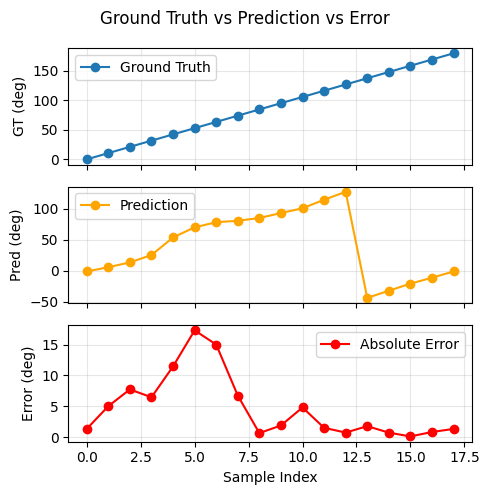

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(5, 5), sharex=True)

axes[0].plot(labels_deg, "o-", label="Ground Truth")
axes[0].set_ylabel("GT (deg)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(preds_deg, "o-", color="orange", label="Prediction")
axes[1].set_ylabel("Pred (deg)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(errors, "o-", color="red", label="Absolute Error")
axes[2].set_xlabel("Sample Index")
axes[2].set_ylabel("Error (deg)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Ground Truth vs Prediction vs Error")
plt.tight_layout()
plt.show()

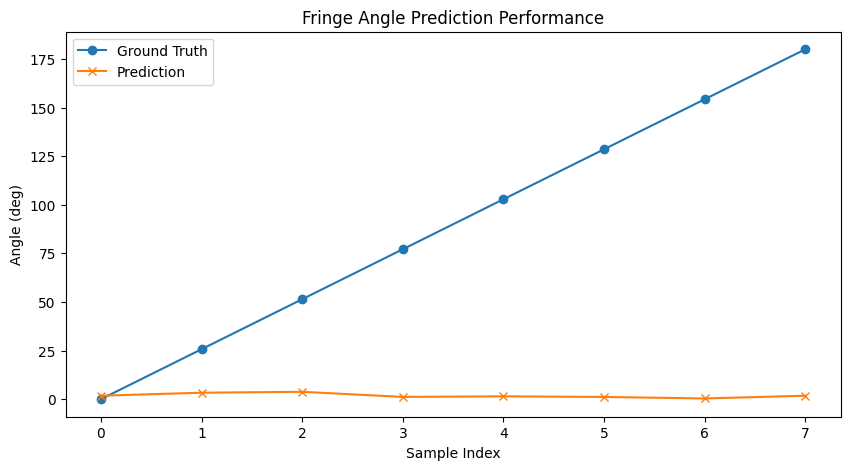

In [31]:
plt.figure(figsize=(10,5))

plt.plot(labels_deg, 'o-', label="Ground Truth")
plt.plot(errors, 'x-', label="error")

plt.xlabel("Sample Index")
plt.ylabel("Angle (deg)")
plt.legend()
plt.title("Fringe Angle Prediction Performance")
plt.show()

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def generate_fringe(size=128, freq=8, angle=0.0, visibility=1.0):
    x = np.linspace(0, 1, size)
    X, Y = np.meshgrid(x, x)

    # rotate coordinates
    Xr = X * np.cos(angle) + Y * np.sin(angle)

    fringe = 1 + visibility * np.cos(2 * np.pi * freq * Xr)

    # normalize
    fringe = (fringe - fringe.min()) / (fringe.max() - fringe.min())

    return fringe.astype(np.float32)

In [24]:
USE_DOUBLED_ANGLE = False  # set True to test improved physics

def encode_angle(theta):
    if USE_DOUBLED_ANGLE:
        return np.array([np.sin(2*theta), np.cos(2*theta)])
    else:
        return np.array([np.sin(theta), np.cos(theta)])


def decode_angle(sin_val, cos_val):
    if USE_DOUBLED_ANGLE:
        return 0.5 * np.arctan2(sin_val, cos_val)
    else:
        return np.arctan2(sin_val, cos_val)

In [25]:
model.eval()
model.to(device)

FringeNet(
  (stem): FringeStem(
    (conv1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (conv2): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (conv3): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (activation): SiLU(inplace=True)
  )
  (stage1): Sequential(
    (0): FringeResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act): SiLU(inplace=True)

In [26]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F


def predict_angle(model, img, device):
    """
    img: numpy array (H, W) grayscale
    returns: angle in degrees
    """

    model.eval()

    img_t = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

    img_t = img_t.to(device)

    with torch.no_grad():

        out = model(img_t)

        out = F.normalize(out, dim=1)

        angle = torch.atan2(out[:, 0], out[:, 1])

        angle = torch.rad2deg(angle)

    return angle.item()

In [27]:
def rotate_image(img, angle_deg):

    h, w = img.shape[:2]

    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    rotated = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    return rotated

In [28]:
def align_to_vertical(model, img, device):

    angle = predict_angle(model, img, device)

    aligned = rotate_image(img, angle)

    return aligned, angle

In [29]:
import matplotlib.pyplot as plt
import cv2
import numpy as np


def preview_alignment(model, image_paths, device, n=10):

    plt.figure(figsize=(10, 3*n))

    for i, path in enumerate(image_paths[:n]):

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        angle = predict_angle(model, img, device)

        aligned = rotate_image(img, angle)

        # ----------------------------
        # Original
        # ----------------------------
        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Original")
        plt.axis("off")

        # ----------------------------
        # Aligned
        # ----------------------------
        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(aligned, cmap='gray')
        plt.title(f"Aligned: {angle:.2f}°")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
import os

def get_images_from_folder(folder):

    exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

    return [
        os.path.join(folder, f)
        for f in sorted(os.listdir(folder))
        if f.lower().endswith(exts)
    ]

In [ ]:
import matplotlib.pyplot as plt
import cv2


def preview_folder(model, folder, device, n=10):

    image_paths = get_images_from_folder(folder)

    plt.figure(figsize=(10, 3*n))

    for i, path in enumerate(image_paths[:n]):

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        angle = predict_angle(model, img, device)

        aligned = rotate_image(img, angle)

        # Original
        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(img, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        # Aligned
        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(aligned, cmap='gray')
        plt.title(f"Aligned: {angle:.2f}°")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

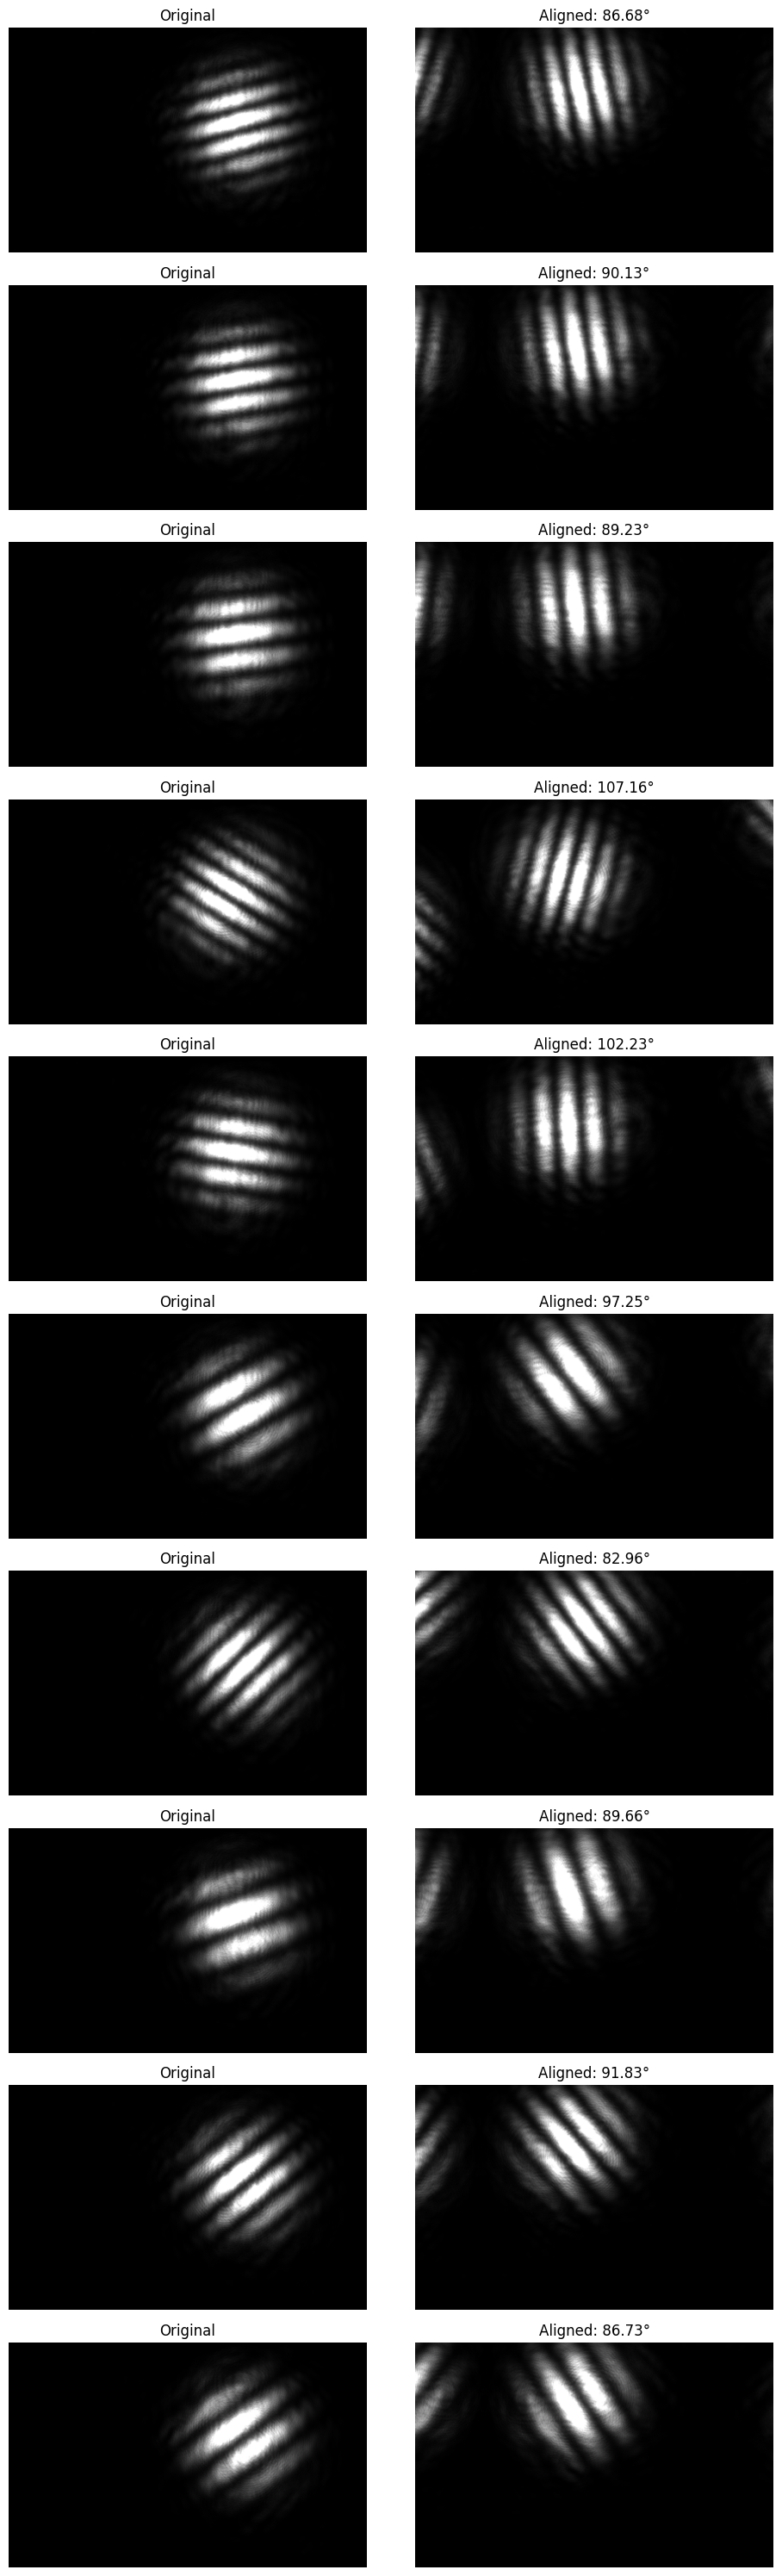

In [35]:
folder_path = r"C:\Users\admin\Desktop\sandeep\data_2\s0hene"

preview_folder(model, folder_path, device, n=10)